# Clustering - advanced notebook

**Datasets source:** https://www.kaggle.com/datasets/rounakbanik/ted-talks?select=transcripts.csv

These datasets contain information about all audio-video recordings of TED Talks uploaded to the official TED.com website until September 21st, 2017. 

`TED main dataset` - contains information about all talks including number of views, number of comments, descriptions, speakers and titles. 

`TED transcripts dataset` - contains the transcripts and url for all talks available on TED.com.

## Load datasets

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

pd.options.display.float_format = '{:.6f}'.format

In [2]:
main_df = pd.read_csv('ted_main.csv')
main_df.head()

,comments,description,duration,event,film_date,languages,main_speaker,name,num_speaker,published_date,ratings,related_talks,speaker_occupation,tags,title,url,views
0,4553,Sir Ken Robinson makes an entertaining and pro...,1164,TED2006,1140825600,60,Ken Robinson,Ken Robinson: Do schools kill creativity?,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 19645}, {...","[{'id': 865, 'hero': 'https://pe.tedcdn.com/im...",Author/educator,"['children', 'creativity', 'culture', 'dance',...",Do schools kill creativity?,https://www.ted.com/talks/ken_robinson_says_sc...,47227110
1,265,With the same humor and humanity he exuded in ...,977,TED2006,1140825600,43,Al Gore,Al Gore: Averting the climate crisis,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 544}, {'i...","[{'id': 243, 'hero': 'https://pe.tedcdn.com/im...",Climate advocate,"['alternative energy', 'cars', 'climate change...",Averting the climate crisis,https://www.ted.com/talks/al_gore_on_averting_...,3200520
2,124,New York Times columnist David Pogue takes aim...,1286,TED2006,1140739200,26,David Pogue,David Pogue: Simplicity sells,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 964}, {'i...","[{'id': 1725, 'hero': 'https://pe.tedcdn.com/i...",Technology columnist,"['computers', 'entertainment', 'interface desi...",Simplicity sells,https://www.ted.com/talks/david_pogue_says_sim...,1636292
3,200,"In an emotionally charged talk, MacArthur-winn...",1116,TED2006,1140912000,35,Majora Carter,Majora Carter: Greening the ghetto,1,1151367060,"[{'id': 3, 'name': 'Courageous', 'count': 760}...","[{'id': 1041, 'hero': 'https://pe.tedcdn.com/i...",Activist for environmental justice,"['MacArthur grant', 'activism', 'business', 'c...",Greening the ghetto,https://www.ted.com/talks/majora_carter_s_tale...,1697550
4,593,You've never seen data presented like this. Wi...,1190,TED2006,1140566400,48,Hans Rosling,Hans Rosling: The best stats you've ever seen,1,1151440680,"[{'id': 9, 'name': 'Ingenious', 'count': 3202}...","[{'id': 2056, 'hero': 'https://pe.tedcdn.com/i...",Global health expert; data visionary,"['Africa', 'Asia', 'Google', 'demo', 'economic...",The best stats you've ever seen,https://www.ted.com/talks/hans_rosling_shows_t...,12005869


In [3]:
transcripts_df = pd.read_csv('transcripts.csv')
transcripts_df.head()

,transcript,url
0,Good morning. How are you?(Laughter)It's been ...,https://www.ted.com/talks/ken_robinson_says_sc...
1,"Thank you so much, Chris. And it's truly a gre...",https://www.ted.com/talks/al_gore_on_averting_...
2,"(Music: ""The Sound of Silence,"" Simon & Garfun...",https://www.ted.com/talks/david_pogue_says_sim...
3,If you're here today — and I'm very happy that...,https://www.ted.com/talks/majora_carter_s_tale...
4,"About 10 years ago, I took on the task to teac...",https://www.ted.com/talks/hans_rosling_shows_t...


## Merging two databeses into one

In [4]:
# Cleaning links in case they differ

main_df['url_clean'] = main_df['url'].str.replace("https://www.ted.com", "", regex=False)
transcripts_df['url_clean'] = transcripts_df['url'].str.replace("https://www.ted.com", "", regex=False)

In [5]:
# Merging databases by URL 

ted = pd.merge(main_df, transcripts_df, on="url_clean", how="inner")

In [6]:
# Choosing significant columns from database

ted = ted[['main_speaker', 'speaker_occupation', 'title', 'views', 'description', 'transcript', 'tags']]
ted.head()

,main_speaker,speaker_occupation,title,views,description,transcript,tags
0,Ken Robinson,Author/educator,Do schools kill creativity?,47227110,Sir Ken Robinson makes an entertaining and pro...,Good morning. How are you?(Laughter)It's been ...,"['children', 'creativity', 'culture', 'dance',..."
1,Al Gore,Climate advocate,Averting the climate crisis,3200520,With the same humor and humanity he exuded in ...,"Thank you so much, Chris. And it's truly a gre...","['alternative energy', 'cars', 'climate change..."
2,David Pogue,Technology columnist,Simplicity sells,1636292,New York Times columnist David Pogue takes aim...,"(Music: ""The Sound of Silence,"" Simon & Garfun...","['computers', 'entertainment', 'interface desi..."
3,Majora Carter,Activist for environmental justice,Greening the ghetto,1697550,"In an emotionally charged talk, MacArthur-winn...",If you're here today — and I'm very happy that...,"['MacArthur grant', 'activism', 'business', 'c..."
4,Hans Rosling,Global health expert; data visionary,The best stats you've ever seen,12005869,You've never seen data presented like this. Wi...,"About 10 years ago, I took on the task to teac...","['Africa', 'Asia', 'Google', 'demo', 'economic..."


In [7]:
# Choosing TED talk, we're gonna work on based on the highest number of views

ted.sort_values("views", ascending=False).head(3)

,main_speaker,speaker_occupation,title,views,description,transcript,tags
0,Ken Robinson,Author/educator,Do schools kill creativity?,47227110,Sir Ken Robinson makes an entertaining and pro...,Good morning. How are you?(Laughter)It's been ...,"['children', 'creativity', 'culture', 'dance',..."
1268,Amy Cuddy,Social psychologist,Your body language may shape who you are,43155405,"Body language affects how others see us, but i...",So I want to start by offering you a free no-t...,"['body language', 'brain', 'business', 'psycho..."
649,Simon Sinek,Leadership expert,How great leaders inspire action,34309432,Simon Sinek has a simple but powerful model fo...,How do you explain when things don't go as we ...,"['TEDx', 'business', 'entrepreneur', 'leadersh..."


## CountVectorizer

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(token_pattern=r"(?u)\b\w+\b", max_features=10000, stop_words=None)

WCmatrix = vectorizer.fit_transform(ted['transcript'])

### Euclidean distance

In [9]:
from sklearn.metrics import pairwise_distances

dskc_index = ted[ted['title'] == 'Do schools kill creativity?'].index[0]

dskc_vector = WCmatrix[dskc_index]

dist = pairwise_distances(dskc_vector, WCmatrix).flatten()

ted = ted.copy()

ted['dskc-eucl'] = dist

In [10]:
ted.sort_values('dskc-eucl').head(10)

,main_speaker,speaker_occupation,title,views,description,transcript,tags,dskc-eucl
0,Ken Robinson,Author/educator,Do schools kill creativity?,47227110,Sir Ken Robinson makes an entertaining and pro...,Good morning. How are you?(Laughter)It's been ...,"['children', 'creativity', 'culture', 'dance',...",0.000000
443,Dan Ariely,Behavioral economist,Are we in control of our own decisions?,4934167,"Behavioral economist Dan Ariely, the author of...",I'll tell you a little bit about irrational be...,"['culture', 'decision-making', 'economics', 'g...",124.715677
825,Christopher McDougall,"Journalist, runner",Are we born to run?,2434842,Christopher McDougall explores the mysteries o...,"Running: it's basically just right, left, righ...","['TEDx', 'entertainment', 'health', 'journalis...",125.083972
1930,Johann Hari,Journalist,Everything you think you know about addiction ...,7841509,What really causes addiction -- to everything ...,One of my earliest memories is of trying to wa...,"['Addiction', 'culture', 'narcotics', 'policy'...",125.670203
1421,Ken Robinson,Author/educator,How to escape education's death valley,6657858,Sir Ken Robinson outlines 3 principles crucial...,Thank you very much.I moved to America 12 year...,"['culture', 'education', 'student', 'teaching'...",126.130884
997,Bunker Roy,Educator,Learning from a barefoot movement,3630894,"In Rajasthan, India, an extraordinary school t...",I'd like to take you to another world. And I'd...,"['culture', 'education', 'global development',...",126.574089
69,Dean Kamen,Inventor,To invent is to give,680134,Inventor Dean Kamen lays out his argument for ...,"As you pointed out, every time you come here, ...","['business', 'cars', 'industrial design', 'inn...",127.964839
663,Ken Robinson,Author/educator,Bring on the learning revolution!,7266316,"In this poignant, funny follow-up to his fable...","I was here four years ago, and I remember, at ...","['TED Brain Trust', 'children', 'creativity', ...",128.191263
639,James Randi,Skeptic and conjuror,"Homeopathy, quackery and fraud",2611707,Legendary skeptic James Randi takes a fatal do...,Good morning. Happy to see so many fine folks ...,"['culture', 'health', 'magic', 'science']",130.376378
2211,Helen Fisher,"Anthropologist, expert on love",Technology hasn't changed love. Here's why,1593458,"In our tech-driven, interconnected world, we'v...",I was recently traveling in the Highlands of N...,"['Internet', 'anthropology', 'communication', ...",130.567990


In [11]:
print(ted[ted['title']=="Do schools kill creativity?"]['tags'].values[0])
print(ted[ted['title']=="Are we in control of our own decisions?"]['tags'].values[0])
print(ted[ted['title']=="Are we born to run?"]['tags'].values[0])

['children', 'creativity', 'culture', 'dance', 'education', 'parenting', 'teaching']
['culture', 'decision-making', 'economics', 'global issues', 'personality', 'psychology', 'science', 'self', 'society']
['TEDx', 'entertainment', 'health', 'journalism', 'science', 'sports']


As we can see, the TED talks closest to Ken Robinson’s “Do schools kill creativity?”, according to the Euclidean distance between their transcripts, are “Are we in control of our own decisions?” by Dan Ariely and “Are we born to run?” by Christopher McDougall.

Based on the tags, titles and small reserach, the first two talks from the table deal with themes related to education, psychology, and human behaviour. Ariely’s talk focuses on decision-making, cognitive biases, and social influences, while Robinson discusses creativity and the structure of modern education systems. McDougall’s talk, on the other hand, centres on physical endurance, health, and evolutionary biology.

The first two talks share psychological and social themes, and they are delivered in a similar narrative style, which results in overlapping vocabulary. The third talk is less closely related in content, as it is primarily about physical fitness and human evolution.

## Top words comparison

In [12]:
def top_words(title):
    text = ted[ted['title'] == title]['transcript'].values[0]
    raw_words = text.split()
    
    ind = {v: i for i, v in enumerate(vectorizer.get_feature_names_out())}
    words = [w for w in raw_words if w in ind]

    index = ted[ted['title'] == title].index[0]
    counts = [WCmatrix[index, ind[w]] for w in words]

    df = pd.Series(counts, index=words).to_frame("count")
    df = df.groupby(df.index).max()
    
    return df.sort_values(by='count', ascending=False)

### Do schools kill creativity?

In [13]:
dskc_words = top_words('Do schools kill creativity?')
dskc_words

,count
the,153
and,103
to,80
you,79
of,75
...,...
adopt,1
according,1
abstract,1
30,1


### Are we in control of our own decisions?

In [14]:
awic_words = top_words("Are we in control of our own decisions?")
awic_words

,count
the,168
you,97
to,95
and,87
we,70
...,...
attracted,1
web,1
weeks,1
whether,1


### Comparison of above TED talk transcripts

In [15]:
common_words = dskc_words.join(awic_words, lsuffix='_dskc', rsuffix='_awic')
common_words.sort_values(by='count_dskc', ascending=False).head(20)

,count_dskc,count_awic
the,153,168.000000
and,103,87.000000
to,80,95.000000
you,79,97.000000
of,75,55.000000
a,74,67.000000
we,63,70.000000
in,56,47.000000
it,52,69.000000
that,46,65.000000


In [16]:
common_words = dskc_words.join(awic_words, lsuffix='_dskc', rsuffix='_awic')
common_words.sort_values(by='count_dskc', ascending=False).head(20)

,count_dskc,count_awic
the,153,168.000000
and,103,87.000000
to,80,95.000000
you,79,97.000000
of,75,55.000000
a,74,67.000000
we,63,70.000000
in,56,47.000000
it,52,69.000000
that,46,65.000000


Within the most frequent words of “Do schools kill creativity?” and “Are we in control of our own decisions?”, we observe mainly basic English function words (such as the, and, to, we, you). There are no rare or more concrete content words that would clearly specify the theme of these TED talks. This suggests that the similarity measured by Euclidean distance is driven primarily by general linguistic structure rather than by topic-specific vocabulary.

### All of the transcripts that contain top 20 common words 

In [17]:
word_to_ind = {v: i for i, v in enumerate(vectorizer.get_feature_names_out())} 

dskc_common = common_words.sort_values(by="count_dskc", ascending=False).head(20)

transcripts = WCmatrix[:, [word_to_ind[word] for word in dskc_common.index]]
transcripts = [i for i, transcript in enumerate(transcripts) if transcript.todense().all()]

print(len(transcripts))

197


In [18]:
ted['title'][transcripts]

0                            Do schools kill creativity?
5                                   Why we do what we do
9                                      A life of purpose
10          My wish: A call for open-source architecture
12                       My wish: Help me stop pandemics
                              ...                       
2399    Don't feel sorry for refugees -- believe in them
2434         The era of blind faith in big data must end
2439                         "The Sacred Art of the Ori"
2441             Fun, fierce and fantastical African art
2458            The fascinating physics of everyday life
Name: title, Length: 197, dtype: object

In [19]:
dskc_common.head(20)

,count_dskc,count_awic
the,153,168.000000
and,103,87.000000
to,80,95.000000
you,79,97.000000
of,75,55.000000
a,74,67.000000
we,63,70.000000
in,56,47.000000
it,52,69.000000
that,46,65.000000


The analysis of the most frequent common words between “Do schools kill creativity?” and “Are we in control of our own decisions?” shows that the shared vocabulary is dominated by basic English function words such as the, and, to, you, we, of, and is. These words appear in a large number of transcripts (197 talks), which indicates that they are highly generic and occur across many TED talks regardless of topic.

## TF-IDF

In [20]:
from sklearn.feature_extraction.text import TfidfTransformer

vectorizer = CountVectorizer(token_pattern=r"(?u)\b\w+\b", stop_words=None)
WCmatrix=vectorizer.fit_transform(ted['transcript'])

tfidf=TfidfTransformer(smooth_idf=False, norm=None)
TFIDFmatrix=tfidf.fit_transform(WCmatrix)

### Euclidean distance using TF-IDF for “Do schools kill creativity?”

In [21]:
dskc_index = ted[ted['title'] == 'Do schools kill creativity?'].index[0]

dskc_vector = TFIDFmatrix[dskc_index]

dist = pairwise_distances(dskc_vector, TFIDFmatrix).flatten()

ted['dskc-eucl-TF-IDF'] = dist

ted[['title', 'main_speaker', 'dskc-eucl-TF-IDF']].sort_values(by='dskc-eucl-TF-IDF').head(10)


,title,main_speaker,dskc-eucl-TF-IDF
0,Do schools kill creativity?,Ken Robinson,0.000000
663,Bring on the learning revolution!,Ken Robinson,256.539464
1421,How to escape education's death valley,Ken Robinson,261.647000
1278,Smart failure for a fast-changing world,Eddie Obeng,270.623818
195,A powerful idea about ideas,Alan Kay,272.570959
879,On being wrong,Kathryn Schulz,274.671133
166,Why aren't we more compassionate?,Daniel Goleman,276.045391
1117,Let's talk about dying,Peter Saul,278.429258
557,A one-man world summit,Rory Bremner,278.591310
227,Designing objects that tell stories,Yves Behar,278.713802


As we can see, the TED talks closest to Ken Robinson’s talk are his own other talks, which makes perfect sense, since he often discusses similar topics. All three focus on learning, creativity, and education.

## Top words comparison with TF-IDF usage

In [22]:
def top_words_tf_idf(title):
    text = ted[ted['title'] == title]['transcript'].values[0]
    raw_words = text.split()

    ind = {v: i for i, v in enumerate(vectorizer.get_feature_names_out())}
    words = [w for w in raw_words if w in ind]

    index = ted[ted['title'] == title].index[0]

    tfidf_values = [TFIDFmatrix[index, ind[w]] for w in words]

    df = pd.Series(tfidf_values, words).to_frame("tf-idf")
    df = df[~df.index.duplicated()]
    
    return df.sort_values(by='tf-idf', ascending=False)

### Common words in "Do schools kill creativity?" and "Bring on the learning revolution!" talks

In [23]:
dskc_tf_idf = top_words_tf_idf("Do schools kill creativity?").rename(columns={'tf-idf': 'tf-idf_dskc'})
botlr_tf_idf = top_words_tf_idf("Bring on the learning revolution!").rename(columns={'tf-idf': 'tf-idf_botlr'})

common_words = dskc_tf_idf.join(botlr_tf_idf, rsuffix="_botlr")
common_words.dropna(inplace=True)

common_sorted = common_words.sort_values(by='tf-idf_dskc', ascending=False)
common_sorted.head(20)

,tf-idf_dskc,tf-idf_botlr
the,153.621447,86.349310
and,103.460289,75.335162
to,80.390086,69.336449
you,79.514032,62.403417
of,75.426830,64.364229
a,74.390978,63.332860
she,73.157584,7.137325
we,64.394319,34.752490
education,59.531227,43.295438
in,56.455843,32.260482


Once again the most common words are mostly basic english funcion words, with only one significant word in the whole array.

### Euclidean distance with TF-IDF between "Do schools kill creativity?" and "Are we in control of our own decisions?"

Since this time with usage of TF-IDF the most similar talks to "Do schools kill creativity?" have changed, I want to check how previously most similar text stands now.

In [24]:
dskc_index = ted[ted['title'] == "Do schools kill creativity?"].index[0]
awic_index = ted[ted['title'] == "Are we in control of our own decisions?"].index[0]

dskc_vec = TFIDFmatrix[dskc_index]
awic_vec = TFIDFmatrix[awic_index]

dist = pairwise_distances(dskc_vec, awic_vec)[0, 0]
dist

np.float64(307.8279745752122)

This time with usage of TF-IDF, euclidean distance between "Do schools kill creativity?" and "Are we in control of our own decisions?" is over 2 times bigger than previous calculation (124.72).

### Common words in "Do schools kill creativity?" and "Are we in control of our own decisions?" talks

In [25]:
dskc_tf_idf = top_words_tf_idf("Do schools kill creativity?").rename(columns={'tf-idf': 'tf-idf_dskc'})
awic_tf_idf = top_words_tf_idf("Are we in control of our own decisions?").rename(columns={'tf-idf': 'tf-idf_awic'})

common_words = dskc_tf_idf.join(awic_tf_idf, rsuffix="_awic")
common_words.dropna(inplace=True)

common_sorted = common_words.sort_values(by='tf-idf_dskc', ascending=False)
common_sorted.head(20)


,tf-idf_dskc,tf-idf_awic
the,153.621447,168.682373
and,103.460289,87.388788
to,80.390086,95.463227
you,79.514032,97.631153
of,75.426830,55.313009
a,74.390978,67.353994
we,64.394319,71.549244
in,56.455843,47.382582
it,52.380799,69.505291
that,46.393245,65.555672


Compare to previous table this one is pretty similar, but it has one notable difference. It doesn't contain any significant (rare) word such as 'education', which we can deduce to have a great impact on the pairwise distance.

### All articles that contain top 20 common words from talks "Do schools kill creativity?" and "Bring on the learning revolution!"

In [26]:
word_to_ind = {v: i for i, v in enumerate(vectorizer.get_feature_names_out())}

common_words = dskc_tf_idf.join(botlr_tf_idf, rsuffix="_botlr")
common_words.dropna(inplace=True)

common_sorted = common_words.sort_values(by="tf-idf_dskc", ascending=False)
top20_words = common_sorted.head(20).index.tolist()

transcripts = np.zeros(TFIDFmatrix.shape[0], dtype=bool)

for i in range(TFIDFmatrix.shape[0]):
    row = TFIDFmatrix[i]
    transcripts[i] = all(row[0, word_to_ind[w]] > 0 for w in top20_words)

transcripts.sum()


np.int64(140)

This time the number of articles containing top 20 common words from our main article and it's new closest neighbour decreased. TF-IDF reduced the influence of frequent, non-informative words.

## Computing length of each document

In [27]:
import re

tokenizer = re.compile(r"(?u)\b\w+\b").findall

def compute_length(row):
    return len(tokenizer(row['transcript']))

ted['length'] = ted.apply(compute_length, axis=1)

In [28]:
nearest_neighbors_euclidean = ted.sort_values(by='dskc-eucl-TF-IDF',ascending=True)[['title','length', 'dskc-eucl-TF-IDF']].head(100)
nearest_neighbors_euclidean

,title,length,dskc-eucl-TF-IDF
0,Do schools kill creativity?,3294,0.000000
663,Bring on the learning revolution!,2729,256.539464
1421,How to escape education's death valley,2857,261.647000
1278,Smart failure for a fast-changing world,2526,270.623818
195,A powerful idea about ideas,2986,272.570959
...,...,...,...
1908,The first secret of design is ... noticing,2643,294.112636
69,To invent is to give,3400,294.147156
77,"Art with wire, sugar, chocolate and string",2380,294.172758
129,How to educate leaders? Liberal arts,2214,294.227146


### Plot of DSKC length vs it's top 100 neighbour's length vs all transctiption's length

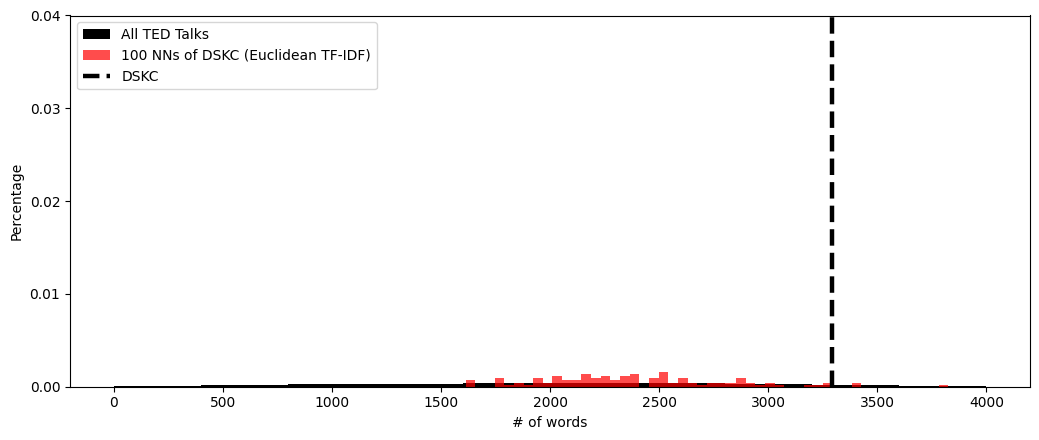

In [29]:
plt.figure(figsize=(10.5,4.5))

plt.hist(ted.length, range=[0, 4000], density=True, color='black', label='All TED Talks')
plt.hist(nearest_neighbors_euclidean.length, bins=50, alpha=0.7, density=True, color='red',
         label='100 NNs of DSKC (Euclidean TF-IDF)')

plt.axvline(ted[ted.title == "Do schools kill creativity?"].length.values[0],
            label='DSKC', color='black', linestyle='--', linewidth=3.2)

plt.xlabel("# of words")
plt.ylabel("Percentage")
plt.yticks(np.arange(0.00, 0.040001, 0.01))
plt.legend()
plt.tight_layout()


All lengths of the transcripts were plotted in black, top 100 neighbours of "Do schools kill creativity?" were plotted in red and black dashed line represents length of DSKC transctipt.

The length of DSKC transcript (around 3300 words) is bigger than it's 100 top neighours lengths (between 2000-2500 words). Euclidean distance tends to select short documents as nearest neighbors, regardless of topic similarity. Since DSKC is relatively long, Euclidean distance fails to pick talks of similar length, explaining why cosine distance is better suited for text similarity.

## Calculating cosine distance (with TD-IDF)

In [30]:
from sklearn.metrics import pairwise_distances

dskc_index = ted[ted['title'] == 'Do schools kill creativity?'].index[0]

dskc_vector = TFIDFmatrix[dskc_index]

cosine_dist = pairwise_distances(dskc_vector, TFIDFmatrix, metric="cosine").flatten()

ted["DSKC-cosine-TF-IDF"] = cosine_dist

nearest_neighbors_cosine = ted.sort_values(by='DSKC-cosine-TF-IDF', ascending=True)[
    ['title', 'main_speaker', 'length', 'description', 'DSKC-cosine-TF-IDF']
].head(100)

nearest_neighbors_cosine


,title,main_speaker,length,description,DSKC-cosine-TF-IDF
0,Do schools kill creativity?,Ken Robinson,3294,Sir Ken Robinson makes an entertaining and pro...,0.000000
364,Design and discovery,David Carson,3826,Great design is a never-ending journey of disc...,0.254717
663,Bring on the learning revolution!,Ken Robinson,2729,"In this poignant, funny follow-up to his fable...",0.255708
1421,How to escape education's death valley,Ken Robinson,2857,Sir Ken Robinson outlines 3 principles crucial...,0.256467
354,Play! Experiment! Discover!,Kary Mullis,5933,Biochemist Kary Mullis talks about the basis o...,0.262267
...,...,...,...,...,...
285,"Once upon a time, my mother ...",Carmen Agra Deedy,3314,"Storyteller Carmen Agra Deedy spins a funny, w...",0.314331
76,Design is in the details,Paul Bennett,2577,"Showing a series of inspiring, unusual and pla...",0.315060
597,Innovating to zero!,Bill Gates,4652,"At TED2010, Bill Gates unveils his vision for ...",0.315060
11,My wish: A global day of film,Jehane Noujaim,4027,Jehane Noujaim unveils her 2006 TED Prize wish...,0.315129


Most of the nearest neighbours are other talks by Ken Robinson, indicating strong similarity in vocabulary and theme. The closest neighbour that is not a Ken Robinson talk is “Design and discovery” by David Carson.

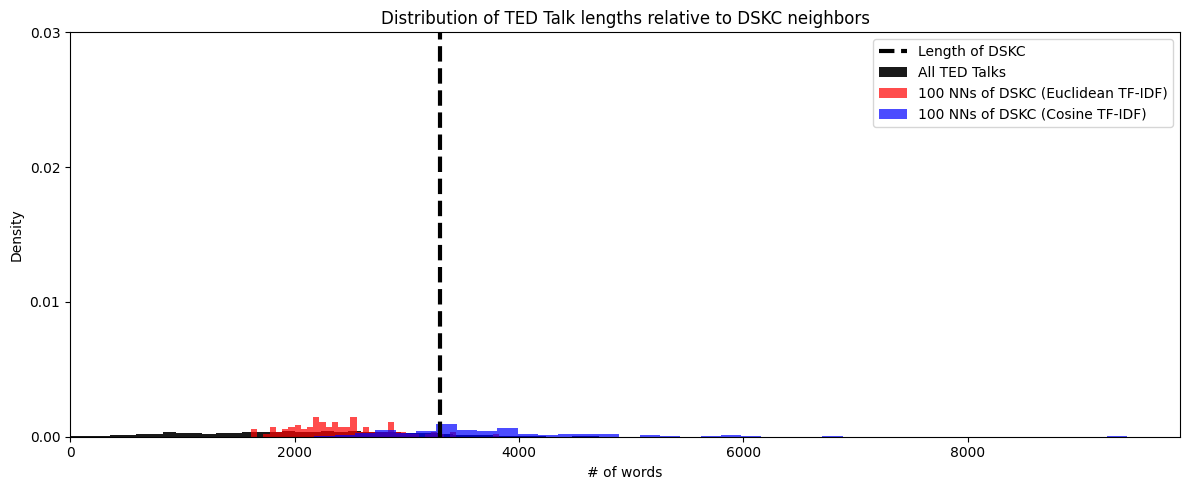

In [31]:
plt.figure(figsize=(12,5))

plt.axvline(
    ted[ted.title == "Do schools kill creativity?"].length.values[0],
    label='Length of DSKC',
    color='black',
    linestyle='--',
    linewidth=3
)

plt.hist(
    ted.length,
    bins=80,
    density=True,
    color='black',
    alpha=0.9,
    label='All TED Talks'
)

plt.hist(
    nearest_neighbors_euclidean.length,
    bins=40,
    alpha=0.7,
    density=True,
    color='red',
    label='100 NNs of DSKC (Euclidean TF-IDF)'
)

plt.hist(
    nearest_neighbors_cosine.length,
    bins=40,
    alpha=0.7,
    density=True,
    color='blue',
    label='100 NNs of DSKC (Cosine TF-IDF)'
)

plt.xlabel("# of words")
plt.ylabel("Density")
plt.title("Distribution of TED Talk lengths relative to DSKC neighbors")
plt.yticks(np.arange(0.0, 0.035, 0.01))
plt.xlim([0, ted.length.max() * 1.05])
plt.legend()
plt.tight_layout()
plt.show()


Cosine similarity reduces the influence of document length because it compares the direction of TF-IDF vectors instead of their size. Thanks to this, the nearest neighbours selected with cosine TF-IDF have transcript lengths that are more similar to “Do Schools Kill Creativity?”.

On the other hand, Euclidean distance is sensitive to the absolute values of vectors, which makes it prefer shorter transcripts as nearest neighbours. This is why cosine similarity produces results that are more thematically consistent and less affected by transcript length.

### Overlap between cosine and Euclidean nearest neighbours

In [32]:
euclidean_set = set(nearest_neighbors_euclidean.index)
cosine_set = set(nearest_neighbors_cosine.index)

overlap = euclidean_set & cosine_set

print(f"Overlap: {len(overlap)} / 100")

Overlap: 28 / 100


The results show that different distance metrics measure similarity in different ways, even when they are applied to the same TF-IDF representation.
The relatively low overlap (28%) means that cosine similarity and Euclidean distance focus on different properties of the document vectors.

# Curse of dimensionality in high-dimensional spaces

In [36]:
import numpy as np

sample_idx = np.random.choice(TFIDFmatrix.shape[0], size=500, replace=False)
sample = TFIDFmatrix[sample_idx]

dists = pairwise_distances(sample, metric="cosine")

upper = dists[np.triu_indices_from(dists, k=1)]

upper.min(), upper.mean(), upper.max()

(np.float64(0.2347315175805632),
 np.float64(0.5685836288273658),
 np.float64(1.0))

Text(0.5, 1.0, 'Distribution of cosine distances in high-dimensional TF-IDF space')

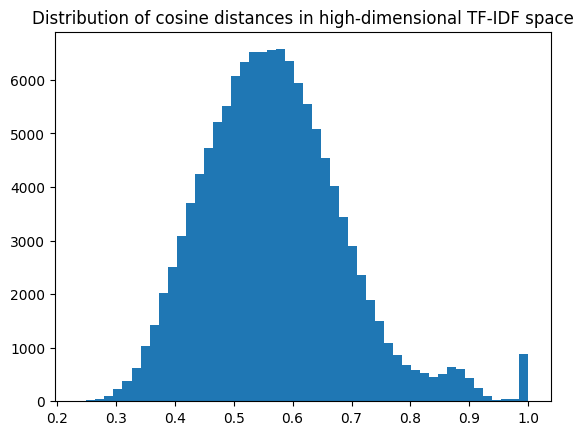

In [37]:
plt.hist(upper, bins=50)
plt.title("Distribution of cosine distances in high-dimensional TF-IDF space")

The distribution of pairwise cosine distances in the TF-IDF space is highly concentrated around a narrow range of values.
This indicates that in a high-dimensional representation most documents are similarly distant from each other, which is a characteristic effect of the curse of dimensionality.

# Distance concentration effect

In [38]:
np.random.seed(42)
sample_idx = np.random.choice(TFIDFmatrix.shape[0], size=500, replace=False)
sample = TFIDFmatrix[sample_idx]

dist_matrix = pairwise_distances(sample, metric="cosine")

upper = dist_matrix[np.triu_indices_from(dist_matrix, k=1)]

upper.min(), upper.mean(), upper.max()

(np.float64(0.20676847919893182),
 np.float64(0.5710787368440621),
 np.float64(1.0))

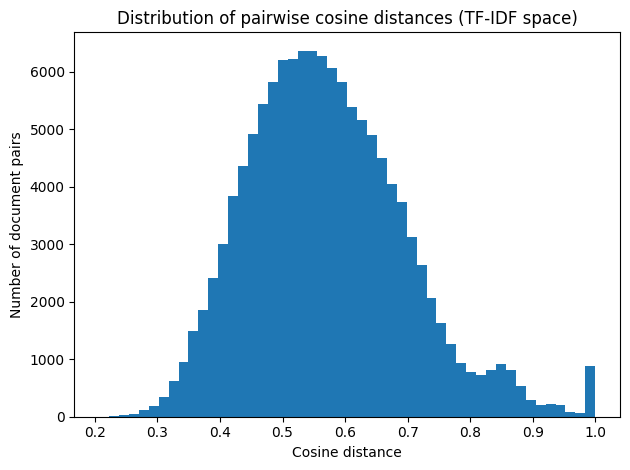

In [ ]:
plt.hist(upper, bins=50)
plt.xlabel("Cosine distance")
plt.ylabel("Number of document pairs")
plt.title("Distribution of pairwise cosine distances (TF-IDF space)")
plt.tight_layout()
plt.show()

The distribution of pairwise cosine distances is highly concentrated, with most values lying in a narrow range around the mean.
This confirms the distance concentration effect and illustrates the curse of dimensionality in high-dimensional TF-IDF space.

# Brute-force NN search complexity

In [45]:
import time

query = TFIDFmatrix[dskc_index]

for n in [200, 500, 1000, 2000]:
    subset = TFIDFmatrix[:n]

    start = time.time()
    _ = pairwise_distances(query, subset, metric="cosine")
    print(n, round(time.time() - start, 4))


200 0.0123
500 0.013
1000 0.0347
2000 0.0663


The runtime of the brute-force nearest neighbour search grows approximately as O(N) with the number of documents.
For small datasets, constant factors dominate the runtime and mask the linear trend.